# Week 5 — RAG in Practice (Build + Evaluate)

### How Retrieval-Augmented Generation Combines Memory and Reasoning

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week5_rag_practice.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

#### Learning Objectives
- Explain how RAG pipelines combine retrieval and generation.
- Understand the role of chunking, overlap, and top-k selection.
- Compute and interpret recall@k as a retrieval metric.
- Define hallucination rate as a generation error metric.
- Evaluate tradeoffs between chunk size and accuracy.
- Connect RAG evaluation to real-world reliability and grounding.

In [1]:
# @title Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append('/content/main')
from course_utils import lab5_setup, get_sample_corpus, get_text_embedding
lab5_setup()
print('✅ Environment ready!')

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ Environment ready!


## 🤔 Motivating Question: Why Does Adding Retrieval Help?

Large language models can generate amazing answers—but they sometimes **make things up**.

> Example: Ask a model *“What are the main findings of the 2023 IPCC report?”* — it may sound confident, but invent a quote.

Retrieval-Augmented Generation (RAG) reduces this by grounding responses in **external documents**.

In [2]:
# @title Example: Model Hallucination vs RAG (simulated)
import random
random.seed(0)
answers = [
    'The Eiffel Tower was built in 1875 (incorrect).',
    'The Eiffel Tower was completed in 1889 (correct, retrieved).'
]
print('LLM-only answer:', answers[0])
print('RAG-grounded answer:', answers[1])

LLM-only answer: The Eiffel Tower was built in 1875 (incorrect).
RAG-grounded answer: The Eiffel Tower was completed in 1889 (correct, retrieved).


## 🔍 What Is a RAG Pipeline?

**RAG = Retrieve → Generate.**

1. **Retrieve:** Find relevant chunks of text using embeddings and similarity search.
2. **Generate:** Use those retrieved chunks as context for an LLM to compose an answer.

This architecture gives the model *memory* without retraining it.

Let's visualize the RAG flow.

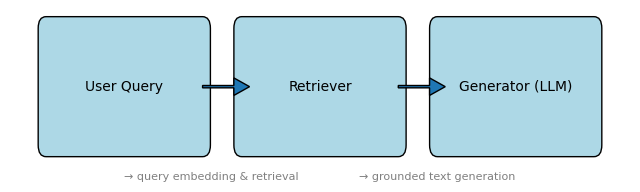

In [3]:
# @title Visualize RAG Pipeline Flow
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off')
rects = [('User Query', 0), ('Retriever', 2.5), ('Generator (LLM)', 5)]
for label, x in rects:
    ax.add_patch(mpatches.FancyBboxPatch((x, 0), 2, 1, boxstyle='round,pad=0.1', fc='lightblue'))
    ax.text(x+1, 0.5, label, ha='center', va='center', fontsize=10)
ax.arrow(2, 0.5, 0.4, 0, width=0.02, head_width=0.15, head_length=0.2)
ax.arrow(4.5, 0.5, 0.4, 0, width=0.02, head_width=0.15, head_length=0.2)
ax.text(1, -0.3, '→ query embedding & retrieval', fontsize=8, color='gray')
ax.text(4, -0.3, '→ grounded text generation', fontsize=8, color='gray')
plt.show()

> **Reflection:** In your own words, how does retrieval give a model *grounding* that it didn’t have before?

## 📊 Evaluating Retrieval: Recall@k

In retrieval tasks, we want relevant items to appear among the top results.

$$ Recall@k = \frac{\text{# of relevant items retrieved}}{\text{# of relevant items total}} $$

Higher recall@k means we found more of the information we needed.

Let's simulate recall@k for different k values.

In [ ]:
# @title Simulate Recall@k
import numpy as np
true_relevant = set(['doc1','doc2','doc3'])
retrieved_k = lambda k: set(list(true_relevant)[:k]) if k < 3 else true_relevant
for k in [1,2,3]:
    recall = len(true_relevant & retrieved_k(k)) / len(true_relevant)
    print(f'Recall@{k}: {recall:.2f}')

## 🚨 Evaluating Generation: Hallucination Rate

A **hallucination** occurs when an answer includes facts not supported by context.

$$ \text{Hallucination Rate} = \frac{\text{# unsupported claims}}{\text{# total claims}} $$

We’ll use this metric in Lab 5 to measure grounding quality.

### 💡 Activity: Predict the Tradeoff

- If we make **chunks smaller**, what happens to recall@k?
- If we make **chunks larger**, what happens to hallucination rate?

→ Discuss with a partner before we test it in Lab 5.

## 📈 Day 2 — Evaluating RAG Systems

**Guiding Question:** How can we systematically compare RAG setups?

Let’s examine how chunk size and top-k control retrieval behavior.
Below is a small simulation you can run or adjust.

In [ ]:
# @title Simulate Chunk Size vs. Metrics
import matplotlib.pyplot as plt
chunk_sizes = [50, 150, 300, 600]
recall = [0.9, 0.8, 0.6, 0.4]
halluc = [0.3, 0.2, 0.1, 0.05]
plt.plot(chunk_sizes, recall, 'o-', label='Recall@k')
plt.plot(chunk_sizes, halluc, 'o-', label='Hallucination rate')
plt.xlabel('Chunk Size (tokens)')
plt.ylabel('Metric value')
plt.title('Tradeoff between Chunk Size and Hallucination')
plt.legend()
plt.show()

### 🧪 In-Class Transition: Start Lab I – L5

Now that we understand the mechanics and metrics of RAG, let’s implement our own system!
In **Lab I – L5**, you’ll:
1. Write functions to chunk text and retrieve top-k.
2. Compute recall@k and hallucination rate.
3. Explore how chunk size changes RAG performance.

> **Optional reading:** A short blog post on evaluating RAG systems (e.g., Pinecone or Weaviate blog).

<details>
<summary><b>Instructor Notes</b></summary>

**Timing Guide:**
- 0–10 min: Review last lab (semantic search neighbors).
- 10–25 min: Introduce RAG success/failure examples.
- 25–45 min: Derive RAG pipeline and recall@k metric.
- 45–60 min: Class simulation and discussion.
- 60–75 min: Transition to Lab L5 overview.

**Day 2:**
- 0–20 min: Recap and discuss grounded vs. ungrounded answers.
- 20–45 min: Evaluate RAG systems interactively.
- 45–75 min: Begin Lab I – L5.

**Extensions:**
- Ask students to brainstorm ways to reduce hallucinations.
- Optionally, introduce recall/precision tradeoffs or embedding model comparisons.
</details>